In [3]:
import pandas as pd

PVGIS_filename = "../data/Timeseries_59.246_18.035_SA3_1kWp_crystSi_14_42deg_0deg_2022_2023.csv"

def process_pvgis (filepath):
    df = pd.read_csv(filepath, header=8, nrows=17520)
    df['time'] = df['time'].astype(str).str[:-2]
    df['time'] = pd.to_datetime(df['time'], format='%Y%m%d:%H')
    df['day_of_year'] = df['time'].dt.dayofyear
    df['hour_of_day'] = df['time'].dt.hour
    X = df[['G(i)', 'day_of_year', 'hour_of_day']]
    y = df[['P']]
    X_train, X_test = X.iloc[:8760], X.iloc[8760:]
    y_train, y_test = y.iloc[:8760], y.iloc[8760:]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = process_pvgis(PVGIS_filename)

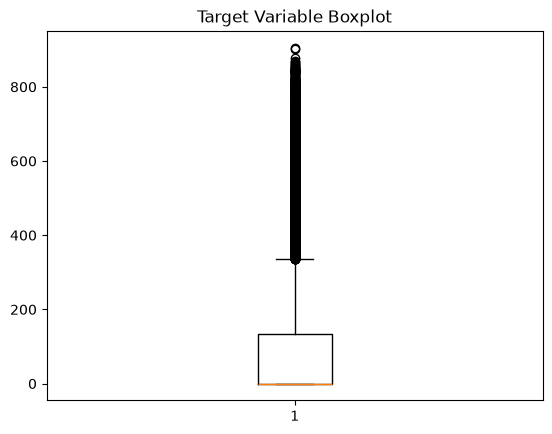

In [5]:
import matplotlib.pyplot as plt
plt.boxplot(y_train)
plt.title("Target Variable Boxplot")
plt.show()

In [13]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(y_train))
outliers = y_train[z_scores > 3]
print(f"Outliers (Z-score > 3): {len(outliers)}")
print(round(len(outliers)/len(y_train)*100, 2), "% Outliers")

Outliers (Z-score > 3): 165
1.88 % Outliers


In [7]:
Q1 = np.percentile(y_train, 25)
Q3 = np.percentile(y_train, 75)
IQR = Q3 - Q1
outliers = y_train[(y_train < Q1 - 1.5 * IQR) | (y_train > Q3 + 1.5 * IQR)]
print(f"Outliers (IQR method): {len(outliers)}")

Outliers (IQR method): 8760


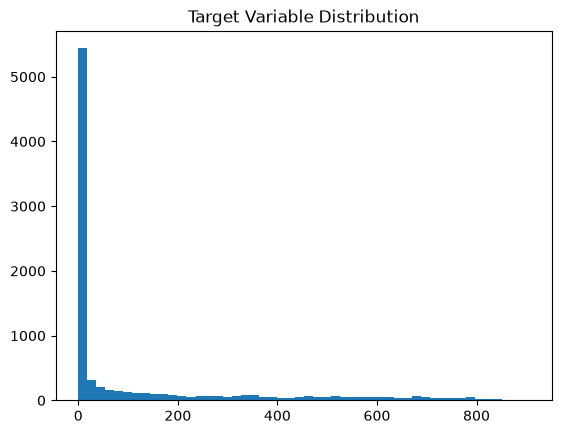

In [8]:
import matplotlib.pyplot as plt
plt.hist(y_train, bins=50)
plt.title("Target Variable Distribution")
plt.show()

In [9]:
from scipy import stats
print(f"Skewness: {stats.skew(y_train.values.ravel()):.2f}")  # >0 = right-skewed, <0 = left-skewed
print(f"Kurtosis: {stats.kurtosis(y_train.values.ravel()):.2f}")  # >0 = heavy-tailed, <0 = light-tailed

Skewness: 1.84
Kurtosis: 2.23
